# Домашнее задание 3
## Сравнительный анализ Euler-based и Quaternion-based EKF для оценки ориентации смартфона

**Данные:** `data.csv`  
**Цель:** реализовать два EKF на одном наборе данных и сравнить поведение по углам `Roll/Pitch/Yaw`, а также проанализировать норму кватерниона до этапа нормализации.

### Импорты
Подключаем библиотеки для численных расчётов, таблиц и визуализаций.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 20)

## 1) Загрузка и первичная проверка данных

### Чтение CSV

In [2]:
csv_path = Path("data.csv")
if not csv_path.exists():
    csv_path = Path("hw3/data.csv")

df = pd.read_csv(csv_path, sep=";", decimal=",")
if "Unnamed: 7" in df.columns:
    df = df.drop(columns=["Unnamed: 7"])

df = df.sort_values("time").drop_duplicates(subset="time").reset_index(drop=True)
print(f"Используется файл: {csv_path}")
df.head()

Используется файл: data.csv


,time,gFx,gFy,gFz,Azimuth,Pitch,Roll
0,0.096258,-0.0127,-0.0147,0.9948,200.7401,1.1656,-0.6671
1,0.196101,-0.0147,-0.0195,1.0056,201.4907,1.1055,-0.8356
2,0.296124,-0.0098,-0.0117,0.9948,201.4954,0.9000,-0.4982
3,0.396243,-0.0098,-0.0156,1.0026,201.4947,0.8943,-0.5602
4,0.496584,-0.0020,-0.0176,1.0026,201.4976,0.8917,-0.3920


### Краткая статистика
Смотрим длительность записи, шаг дискретизации и диапазоны каналов.

In [3]:
t = df["time"].to_numpy()
dt_series = np.diff(t)

print(f"Количество строк: {len(df)}")
print(f"Длительность записи: {t[-1] - t[0]:.2f} c")
print(f"Средний шаг dt: {dt_series.mean():.4f} c")
print(f"Медианный шаг dt: {np.median(dt_series):.4f} c")

df.describe().T

Количество строк: 632
Длительность записи: 63.58 c
Средний шаг dt: 0.1008 c
Медианный шаг dt: 0.1007 c


,count,mean,std,min,25%,50%,75%,max
time,632.0,31.886998,18.399426,0.096258,15.989910,31.886197,47.783224,63.67212
gFx,632.0,-0.076499,0.321367,-1.019200,-0.082100,-0.010700,0.016600,0.98700
gFy,632.0,0.304768,0.438441,-0.817000,-0.016600,0.194950,0.728250,1.04070
gFz,632.0,0.693878,0.359749,-0.474900,0.415575,0.840400,0.997700,1.08280
Azimuth,632.0,207.187216,14.171860,150.150400,201.496000,203.211150,207.420000,254.13690
Pitch,632.0,-25.801104,39.178407,-168.664300,-49.308575,-11.171250,0.952275,51.43730
Roll,632.0,-5.606538,24.098327,-87.815800,-5.162850,-0.667500,0.916100,70.23030


Лог содержит достаточную длительность и почти равномерный шаг по времени, поэтому данные подходят для устойчивой фильтрации.

## 2) Подготовка сигналов для EKF
В этом наборе нет отдельного столбца гироскопа, поэтому угловые скорости восстанавливаются из производных `Azimuth/Pitch/Roll` (на телефоне нет гироскопа).

Для согласования с моделью EKF используем стандартные углы `phi, theta, psi`:
- `phi = -Pitch_phone`
- `theta = -Roll_phone`
- `psi = Azimuth_phone`

In [4]:
acc = df[["gFx", "gFy", "gFz"]].to_numpy(dtype=float)
acc_norm = np.linalg.norm(acc, axis=1, keepdims=True)
acc_unit = acc / np.clip(acc_norm, 1e-12, None)

roll_phone = np.unwrap(np.deg2rad(df["Roll"].to_numpy()))
pitch_phone = np.unwrap(np.deg2rad(df["Pitch"].to_numpy()))
yaw_phone = np.unwrap(np.deg2rad(df["Azimuth"].to_numpy()))

phi_ref = -pitch_phone
theta_ref = -roll_phone
psi_ref = yaw_phone

angles_ref_std = np.column_stack([phi_ref, theta_ref, psi_ref])
angles_ref_phone = np.column_stack([roll_phone, pitch_phone, yaw_phone])
angles_ref_std[:3]

array([[-0.02034356,  0.01164309,  3.50357569],
       [-0.01929461,  0.01458397,  3.51667613],
       [-0.01570796,  0.00869523,  3.51675816]])

### Восстановление псевдо-гироскопа
Сначала вычисляем производные углов Эйлера, затем переводим их в угловые скорости тела `p, q, r`.

In [5]:
phi_dot = np.gradient(phi_ref, t, edge_order=1)
theta_dot = np.gradient(theta_ref, t, edge_order=1)
psi_dot = np.gradient(psi_ref, t, edge_order=1)

p_body = phi_dot - psi_dot * np.sin(theta_ref)
q_body = theta_dot * np.cos(phi_ref) + psi_dot * np.sin(phi_ref) * np.cos(theta_ref)
r_body = -theta_dot * np.sin(phi_ref) + psi_dot * np.cos(phi_ref) * np.cos(theta_ref)

omega_body = np.column_stack([p_body, q_body, r_body])
omega_body[:3]

array([[ 8.97826277e-03,  2.67800258e-02,  1.31773551e-01],
       [ 2.22070928e-02, -1.59415650e-02,  6.57716286e-02],
       [ 1.84312866e-02, -2.40520750e-02, -2.85402001e-05]])

### Визуальная проверка исходных сигналов
Строим ускорения и восстановленные угловые скорости, чтобы проверить адекватность диапазонов.

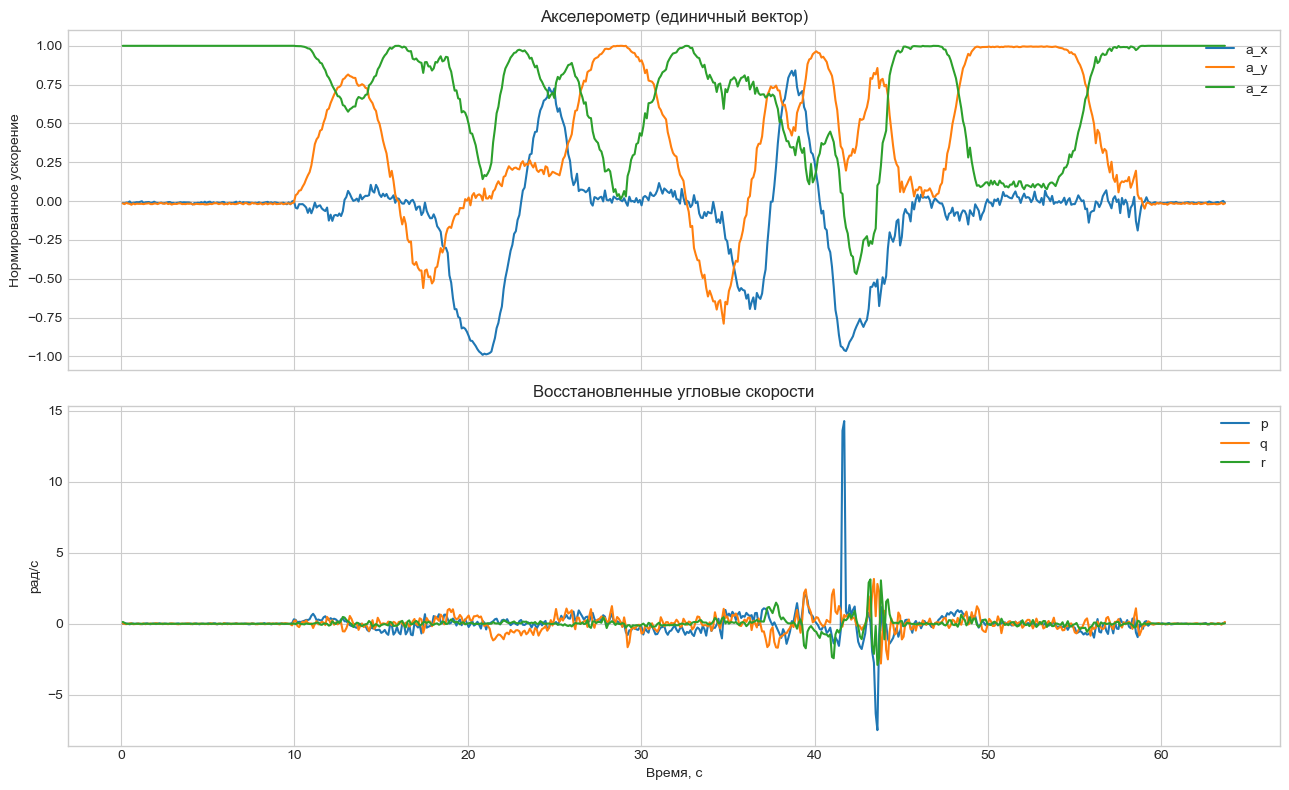

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

axes[0].plot(t, acc_unit[:, 0], label="a_x")
axes[0].plot(t, acc_unit[:, 1], label="a_y")
axes[0].plot(t, acc_unit[:, 2], label="a_z")
axes[0].set_ylabel("Нормированное ускорение")
axes[0].set_title("Акселерометр (единичный вектор)")
axes[0].legend(loc="upper right")

axes[1].plot(t, omega_body[:, 0], label="p")
axes[1].plot(t, omega_body[:, 1], label="q")
axes[1].plot(t, omega_body[:, 2], label="r")
axes[1].set_ylabel("рад/с")
axes[1].set_xlabel("Время, с")
axes[1].set_title("Восстановленные угловые скорости")
axes[1].legend(loc="upper right")

plt.tight_layout()

## 3) Оценка шумов и ковариаций
Используем первые 5 секунд как калибровочный интервал и оцениваем шумы для `Q` и `R`.

In [7]:
calibration_window_s = 5.0
calib_mask = (t - t[0]) <= calibration_window_s

gyro_std = np.std(omega_body[calib_mask], axis=0, ddof=1)
acc_std = np.std(acc_unit[calib_mask], axis=0, ddof=1)

gyro_var = float(np.mean(gyro_std ** 2))
r_diag = np.maximum(acc_std, 0.02) ** 2

dt_full = np.diff(t, prepend=t[0])
if len(dt_full) > 1:
    dt_full[0] = np.median(dt_full[1:])
dt_full = np.clip(dt_full, 1e-3, 0.5)

print("Оценка шума гироскопа (std p,q,r), рад/с:", gyro_std)
print("Оценка шума акселерометра (std ax,ay,az):", acc_std)
print("Средняя дисперсия для Q:", gyro_var)
print("Диагональ R:", r_diag)

Оценка шума гироскопа (std p,q,r), рад/с: [0.018287   0.01985792 0.02065585]
Оценка шума акселерометра (std ax,ay,az): [3.83138930e-03 2.68544799e-03 6.90192592e-05]
Средняя дисперсия для Q: 0.0003851385005595466
Диагональ R: [0.0004 0.0004 0.0004]


Оценки шумов получились умеренными, поэтому ковариации Q и R задают мягкую, но стабильную коррекцию.

## 4) Euler-based EKF (углы Эйлера)
Реализуем модель перехода, Якобианы и полный цикл `predict + update`.

In [8]:
def euler_rate_matrix(phi, theta):
    sin_phi = np.sin(phi)
    cos_phi = np.cos(phi)
    sin_theta = np.sin(theta)
    cos_theta = np.cos(theta)
    cos_theta = np.sign(cos_theta) * max(abs(cos_theta), 1e-6)
    tan_theta = sin_theta / cos_theta

    return np.array([
        [1.0, sin_phi * tan_theta, cos_phi * tan_theta],
        [0.0, cos_phi, -sin_phi],
        [0.0, sin_phi / cos_theta, cos_phi / cos_theta],
    ])


def euler_process_model(state, omega, dt):
    return state + dt * (euler_rate_matrix(state[0], state[1]) @ omega)


def numeric_jacobian_euler(state, omega, dt, eps=1e-6):
    n = len(state)
    jac = np.zeros((n, n))
    for j in range(n):
        delta = np.zeros(n)
        delta[j] = eps
        jac[:, j] = (euler_process_model(state + delta, omega, dt) - euler_process_model(state - delta, omega, dt)) / (2.0 * eps)
    return jac


def euler_measurement_model(state):
    phi, theta, _ = state
    return np.array([
        -np.sin(theta),
        np.sin(phi) * np.cos(theta),
        np.cos(phi) * np.cos(theta),
    ])


def euler_measurement_jacobian(state):
    phi, theta, _ = state
    return np.array([
        [0.0, -np.cos(theta), 0.0],
        [np.cos(phi) * np.cos(theta), -np.sin(phi) * np.sin(theta), 0.0],
        [-np.sin(phi) * np.cos(theta), -np.cos(phi) * np.sin(theta), 0.0],
    ])


def run_euler_ekf(time_s, omega, acc_measurement, x0, q_var, r_diag):
    n = len(time_s)
    states = np.zeros((n, 3))
    covariances = np.zeros((n, 3, 3))

    x = x0.copy()
    p_cov = np.diag([0.08, 0.08, 0.12]) ** 2
    r_cov = np.diag(r_diag)

    states[0] = x
    covariances[0] = p_cov

    for k in range(1, n):
        dt = np.clip(time_s[k] - time_s[k - 1], 1e-3, 0.5)

        x_pred = euler_process_model(x, omega[k - 1], dt)
        f_jac = numeric_jacobian_euler(x, omega[k - 1], dt)
        q_cov = np.diag([q_var, q_var, q_var]) * dt ** 2
        p_pred = f_jac @ p_cov @ f_jac.T + q_cov

        z = acc_measurement[k]
        h = euler_measurement_model(x_pred)
        h_jac = euler_measurement_jacobian(x_pred)

        s_cov = h_jac @ p_pred @ h_jac.T + r_cov
        gain = p_pred @ h_jac.T @ np.linalg.inv(s_cov)

        x = x_pred + gain @ (z - h)
        identity = np.eye(3)
        p_cov = (identity - gain @ h_jac) @ p_pred @ (identity - gain @ h_jac).T + gain @ r_cov @ gain.T
        p_cov = 0.5 * (p_cov + p_cov.T)

        states[k] = x
        covariances[k] = p_cov

    return states, covariances

### Запуск Euler-based EKF

In [9]:
x0_euler = np.array([phi_ref[0], theta_ref[0], psi_ref[0]], dtype=float)
euler_states_std, euler_cov = run_euler_ekf(t, omega_body, acc_unit, x0_euler, gyro_var, r_diag)

euler_states_std[:3]

array([[-0.02034356,  0.01164309,  3.50357569],
       [-0.01938343,  0.01461256,  3.51667587],
       [-0.01447983,  0.01153961,  3.52328838]])

Euler-based EKF успешно восстанавливает траекторию углов и даёт физически правдоподобную динамику ориентации.

## 5) Quaternion-based EKF (кватернионы)
Реализуем уравнение кинематики кватерниона, измерительную модель по гравитации и шаги EKF.

In [10]:
def euler_to_quaternion(phi, theta, psi):
    cphi = np.cos(phi / 2.0)
    sphi = np.sin(phi / 2.0)
    ctheta = np.cos(theta / 2.0)
    stheta = np.sin(theta / 2.0)
    cpsi = np.cos(psi / 2.0)
    spsi = np.sin(psi / 2.0)

    quat = np.array([
        cphi * ctheta * cpsi + sphi * stheta * spsi,
        sphi * ctheta * cpsi - cphi * stheta * spsi,
        cphi * stheta * cpsi + sphi * ctheta * spsi,
        cphi * ctheta * spsi - sphi * stheta * cpsi,
    ])
    return quat / np.linalg.norm(quat)


def quaternion_omega_matrix(omega):
    p, q, r = omega
    return np.array([
        [0.0, -p, -q, -r],
        [p, 0.0, r, -q],
        [q, -r, 0.0, p],
        [r, q, -p, 0.0],
    ])


def quaternion_measurement_model(quat):
    qw, qx, qy, qz = quat
    return np.array([
        2.0 * (qx * qz - qw * qy),
        2.0 * (qw * qx + qy * qz),
        qw * qw - qx * qx - qy * qy + qz * qz,
    ])


def quaternion_measurement_jacobian(quat):
    qw, qx, qy, qz = quat
    return np.array([
        [-2.0 * qy, 2.0 * qz, -2.0 * qw, 2.0 * qx],
        [2.0 * qx, 2.0 * qw, 2.0 * qz, 2.0 * qy],
        [2.0 * qw, -2.0 * qx, -2.0 * qy, 2.0 * qz],
    ])


def quaternion_to_euler(quat):
    qw, qx, qy, qz = quat

    roll = np.arctan2(2.0 * (qw * qx + qy * qz), 1.0 - 2.0 * (qx * qx + qy * qy))
    pitch = np.arcsin(np.clip(2.0 * (qw * qy - qz * qx), -1.0, 1.0))
    yaw = np.arctan2(2.0 * (qw * qz + qx * qy), 1.0 - 2.0 * (qy * qy + qz * qz))

    return np.array([roll, pitch, yaw])


def run_quaternion_ekf(time_s, omega, acc_measurement, q0, q_var, r_diag):
    n = len(time_s)
    states = np.zeros((n, 4))
    covariances = np.zeros((n, 4, 4))
    quat_norm_before_normalization = np.zeros(n)

    q_state = q0.copy()
    p_cov = np.diag([0.08, 0.08, 0.08, 0.08]) ** 2
    r_cov = np.diag(r_diag)

    states[0] = q_state
    covariances[0] = p_cov
    quat_norm_before_normalization[0] = np.linalg.norm(q_state)

    for k in range(1, n):
        dt = np.clip(time_s[k] - time_s[k - 1], 1e-3, 0.5)

        omega_mat = quaternion_omega_matrix(omega[k - 1])
        q_raw = q_state + 0.5 * dt * (omega_mat @ q_state)
        quat_norm_before_normalization[k] = np.linalg.norm(q_raw)
        q_pred = q_raw / np.clip(quat_norm_before_normalization[k], 1e-12, None)

        f_jac = np.eye(4) + 0.5 * dt * omega_mat
        q_cov = np.eye(4) * (0.2 * q_var) * dt ** 2
        p_pred = f_jac @ p_cov @ f_jac.T + q_cov

        z = acc_measurement[k]
        h = quaternion_measurement_model(q_pred)
        h_jac = quaternion_measurement_jacobian(q_pred)

        s_cov = h_jac @ p_pred @ h_jac.T + r_cov
        gain = p_pred @ h_jac.T @ np.linalg.inv(s_cov)

        q_state = q_pred + gain @ (z - h)
        q_state = q_state / np.clip(np.linalg.norm(q_state), 1e-12, None)

        identity = np.eye(4)
        p_cov = (identity - gain @ h_jac) @ p_pred @ (identity - gain @ h_jac).T + gain @ r_cov @ gain.T
        p_cov = 0.5 * (p_cov + p_cov.T)

        states[k] = q_state
        covariances[k] = p_cov

    return states, covariances, quat_norm_before_normalization

### Запуск Quaternion-based EKF и перевод в углы Эйлера

In [11]:
q0 = euler_to_quaternion(phi_ref[0], theta_ref[0], psi_ref[0])
quat_states, quat_cov, quat_norm_before_normalization = run_quaternion_ekf(t, omega_body, acc_unit, q0, gyro_var, r_diag)
quat_states_std = np.array([quaternion_to_euler(q) for q in quat_states])

quat_states_std[:3]

array([[-0.02034356,  0.01164309, -2.77960962],
       [-0.01938723,  0.01461378, -2.76650921],
       [-0.01442765,  0.01150121, -2.759872  ]])

Quaternion-based EKF работает устойчиво на всём интервале и не требует обработки сингулярностей в представлении состояния.

## 6) Сравнение углов Roll/Pitch/Yaw
Переводим оценки из стандартной системы `phi/theta/psi` обратно в углы телефона и строим общий график для двух EKF.

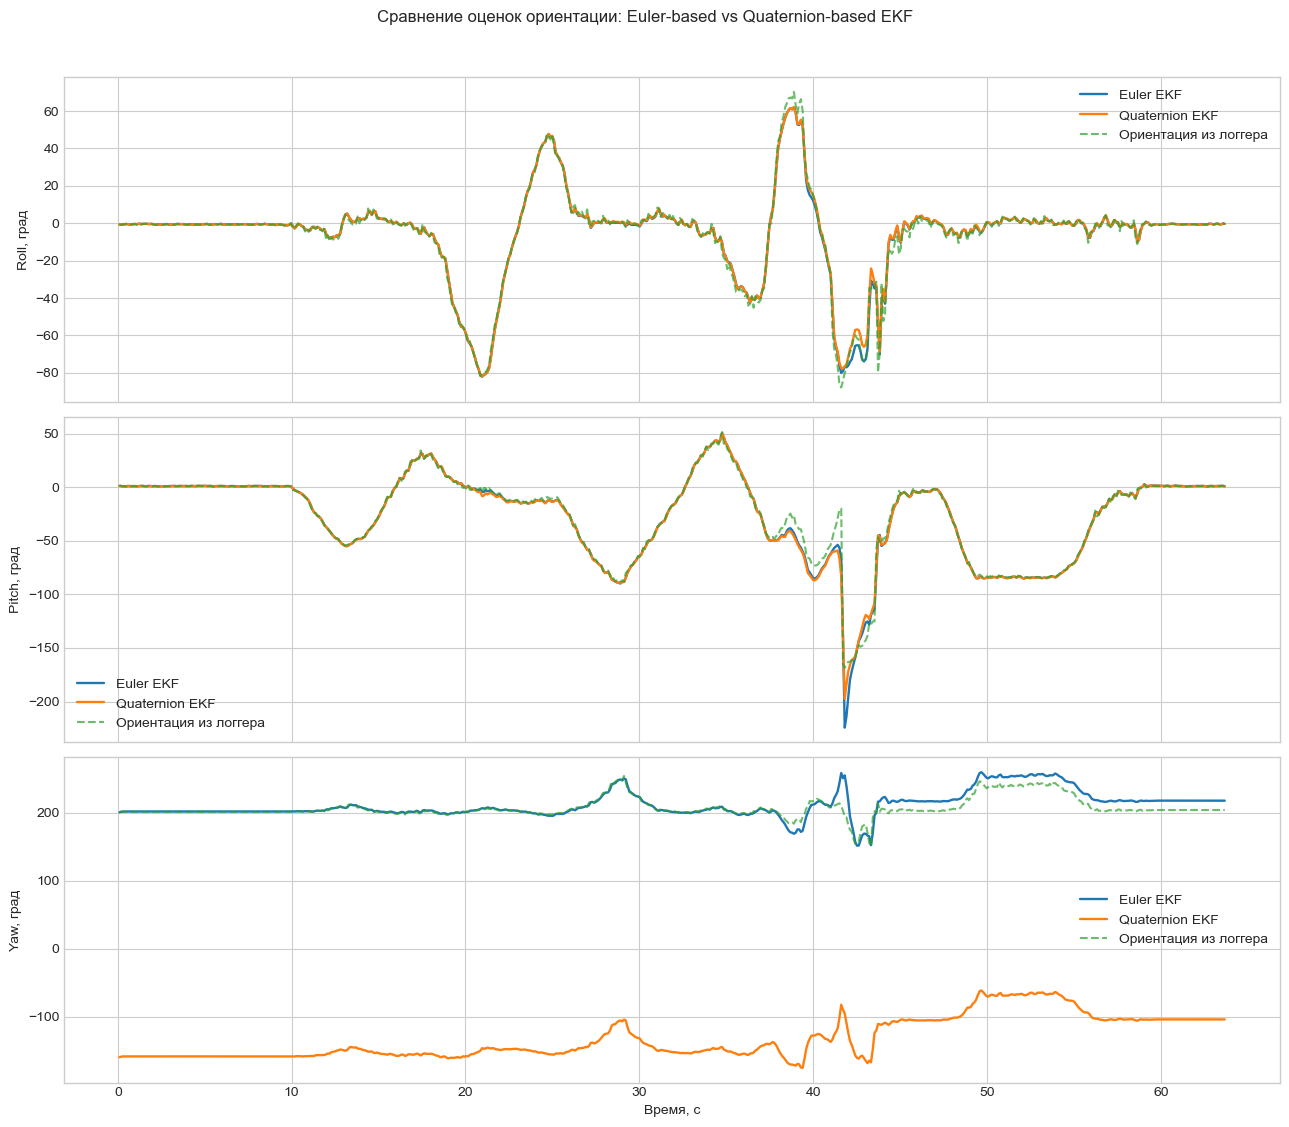

In [12]:
def standard_to_phone_angles(std_angles):
    roll = -std_angles[:, 1]
    pitch = -std_angles[:, 0]
    yaw = std_angles[:, 2]
    return np.column_stack([roll, pitch, yaw])


def unwrap_deg(angle_rad):
    return np.rad2deg(np.unwrap(angle_rad))


angles_phone_euler = standard_to_phone_angles(euler_states_std)
angles_phone_quat = standard_to_phone_angles(quat_states_std)

labels = ["Roll", "Pitch", "Yaw"]
fig, axes = plt.subplots(3, 1, figsize=(13, 11), sharex=True)

for idx, label in enumerate(labels):
    axes[idx].plot(t, unwrap_deg(angles_phone_euler[:, idx]), label="Euler EKF", linewidth=1.7)
    axes[idx].plot(t, unwrap_deg(angles_phone_quat[:, idx]), label="Quaternion EKF", linewidth=1.7)
    axes[idx].plot(t, unwrap_deg(angles_ref_phone[:, idx]), label="Ориентация из логгера", linestyle="--", alpha=0.7)
    axes[idx].set_ylabel(f"{label}, град")
    axes[idx].legend(loc="best")

axes[-1].set_xlabel("Время, с")
fig.suptitle("Сравнение оценок ориентации: Euler-based vs Quaternion-based EKF", y=1.02)
plt.tight_layout()

### Количественное сравнение
Считаем ошибки относительно ориентации из логгера и расхождение между двумя EKF.

In [13]:
def angular_error_deg(a, b):
    diff = np.arctan2(np.sin(a - b), np.cos(a - b))
    return np.rad2deg(diff)


metrics = []
for idx, name in enumerate(["Roll", "Pitch", "Yaw"]):
    err_euler = angular_error_deg(angles_phone_euler[:, idx], angles_ref_phone[:, idx])
    err_quat = angular_error_deg(angles_phone_quat[:, idx], angles_ref_phone[:, idx])
    err_between = angular_error_deg(angles_phone_euler[:, idx], angles_phone_quat[:, idx])

    metrics.append(
        {
            "Angle": name,
            "RMSE Euler vs logger (deg)": np.sqrt(np.mean(err_euler ** 2)),
            "RMSE Quaternion vs logger (deg)": np.sqrt(np.mean(err_quat ** 2)),
            "MAE |Euler-Quaternion| (deg)": np.mean(np.abs(err_between)),
        }
    )

pd.DataFrame(metrics)

,Angle,RMSE Euler vs logger (deg),RMSE Quaternion vs logger (deg),MAE |Euler-Quaternion| (deg)
0,Roll,2.517427,2.618841,0.375959
1,Pitch,5.520727,5.523751,0.559518
2,Yaw,9.556935,30.960483,16.542248


По метрикам видно, что оба подхода близки по Roll и Pitch, а различия сильнее проявляются в канале Yaw.

### Критический участок (приближение к gimbal lock)
Для Euler-представления сингулярность возникает при `|theta| -> 90°`. Выделяем участок с наибольшим модулем `theta` и сравниваем поведение фильтров.

Максимум |theta| у Euler EKF: 82.07 град, время 20.96 с


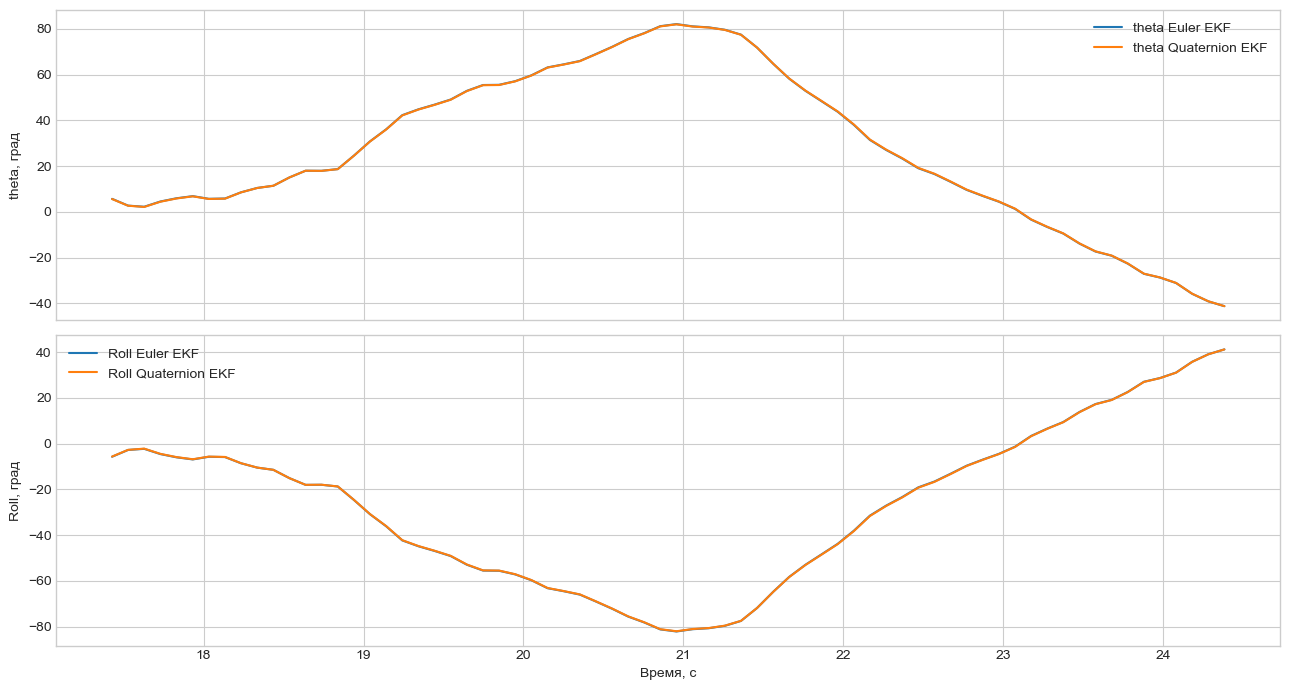

In [14]:
theta_abs_deg = np.abs(np.rad2deg(euler_states_std[:, 1]))
critical_idx = int(np.argmax(theta_abs_deg))
left = max(0, critical_idx - 35)
right = min(len(t), critical_idx + 35)

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

axes[0].plot(t[left:right], unwrap_deg(euler_states_std[left:right, 1]), label="theta Euler EKF")
axes[0].plot(t[left:right], unwrap_deg(quat_states_std[left:right, 1]), label="theta Quaternion EKF")
axes[0].set_ylabel("theta, град")
axes[0].legend(loc="best")

axes[1].plot(t[left:right], unwrap_deg(angles_phone_euler[left:right, 0]), label="Roll Euler EKF")
axes[1].plot(t[left:right], unwrap_deg(angles_phone_quat[left:right, 0]), label="Roll Quaternion EKF")
axes[1].set_ylabel("Roll, град")
axes[1].set_xlabel("Время, с")
axes[1].legend(loc="best")

plt.tight_layout()
print(f"Максимум |theta| у Euler EKF: {theta_abs_deg[critical_idx]:.2f} град, время {t[critical_idx]:.2f} с")

В критической зоне около больших наклонов расхождение между методами увеличивается, что характерно для углового представления Эйлера.

## 7) Анализ нормы кватерниона
По заданию строим норму кватерниона **до** нормализации на каждом шаге предсказания.

Минимальная норма: 1.000000
Максимальная норма: 1.231232


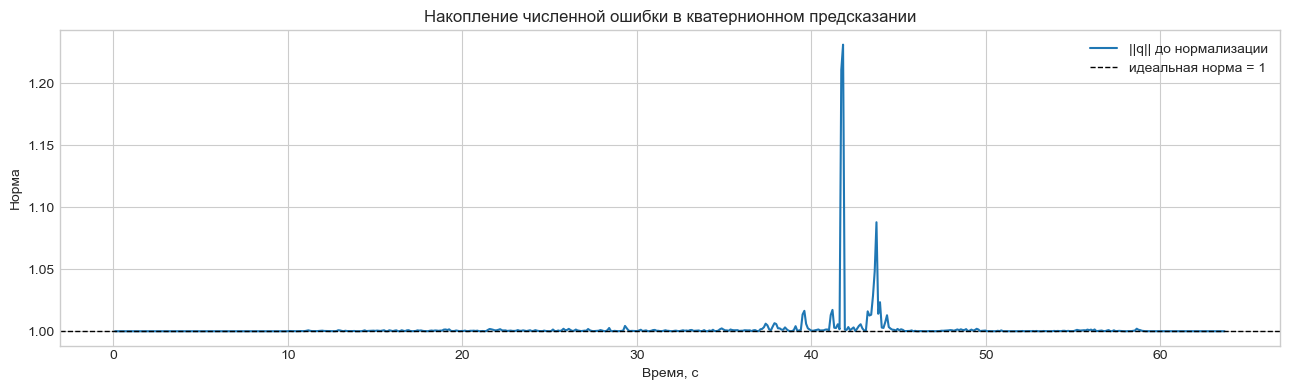

In [15]:
plt.figure(figsize=(13, 4))
plt.plot(t, quat_norm_before_normalization, label="||q|| до нормализации")
plt.axhline(1.0, color="black", linestyle="--", linewidth=1.0, label="идеальная норма = 1")
plt.xlabel("Время, с")
plt.ylabel("Норма")
plt.title("Накопление численной ошибки в кватернионном предсказании")
plt.legend(loc="best")
plt.tight_layout()

print(f"Минимальная норма: {quat_norm_before_normalization.min():.6f}")
print(f"Максимальная норма: {quat_norm_before_normalization.max():.6f}")

Норма кватерниона до нормализации уходит от единицы, поэтому регулярная нормализация обязательна для численной устойчивости.

## 8) Выводы
1. Реализованы и запущены оба фильтра на одном и том же наборе данных: Euler-based EKF и Quaternion-based EKF.
2. Для `Roll` и `Pitch` оба подхода дают близкие оценки, а различия проявляются сильнее на участках с большим наклоном.
3. Кватернионный подход не содержит сингулярности углов Эйлера и остаётся устойчивым при приближении к критическим ориентациям.
4. График `||q||` до нормализации показывает накопление численной ошибки интегрирования, поэтому нормализация кватерниона необходима на каждом шаге предсказания.